In [ ]:
%pip install torch

: 

In [ ]:
import torch
import numpy as np
print(torch.__version__)
print(np.__version__)

: 

In [ ]:
!curl -O https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

: 

In [ ]:
#Get our words as a python list
words = open('names.txt', "r").read().splitlines()

: 

In [ ]:
words[:10]

: 

In [ ]:
#Number of names
len(words)

: 

In [ ]:
#Shortest name
min(len(w) for w in words)

: 

In [ ]:
#Longest name
max(len(w) for w in words)

: 

In [ ]:
#Starting with a bigram language model. This looks at 2 characters at a time.
b = {}
for w in words: #Looks at the first 3 words
    chs = ['<S>'] + list(w) + ['<E>'] #Adds a special start and end to each word
    for ch1, ch2 in zip(chs, chs[1:]):(ch1, ch2)
    #Counts how many of each letter there are
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

: 

In [ ]:
sorted(b.items(), key = lambda kv: -kv[1])

: 

In [ ]:
N = torch.zeros((27, 27), dtype=torch.int32)


: 

In [ ]:
chars = sorted(list(set(''.join(words))))
#string to integer
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.' ] = 0
itos = {i:s for s, i in stoi.items()}

: 

In [ ]:

for w in words: #Looks at the first 3 words
    chs = ['.'] + list(w) + ['.'] #Adds a special start and end to each word
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
    #Counts how many of each letter there are
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

: 

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


: 

In [ ]:
plt.figure(figsize=(16, 16))
plt.imshow(N.tolist(), cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis(False)


: 

In [ ]:
p = N[0].float()
#makes the numbers add to one, making it a probability
p = p / p.sum()
p

: 

In [ ]:
g = torch.Generator().manual_seed(42)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

: 

In [ ]:
g = torch.Generator().manual_seed(42)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

: 

In [ ]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

: 

In [ ]:
P = (N+1).float()
P /=  P.sum(1, keepdim=True)
# P = P / P.sum

: 

In [ ]:

for i in range(5):

    ix = 0
    out = []

    while True:

        p = P[ix]
        # p = N[ix].float()

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

: 

In [ ]:
log_likelihood = 0.0
n = 0
for w in words: #Looks at the first 3 words
    chs = ['.'] + list(w) + ['.'] #Adds a special start and end to each word
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1 
        # print(f"{ch1}{ch2}: {prob: .4f} {logprob: .4f}")

print(f'{log_likelihood = }')
nll = -log_likelihood
print(f"{nll = }")
print(f"{nll/n}")


: 

In [ ]:
#Create the training set of all bigrams
xs, ys = [], []

for w in words[:1]: #Looks at the first 3 words
    chs = ['.'] + list(w) + ['.'] #Adds a special start and end to each word
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

: 

In [ ]:
xs

tensor([ 0,  5, 13, 13,  1])

In [ ]:
ys

tensor([ 5, 13, 13,  1,  0])

In [ ]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() #xenc for x encoded
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

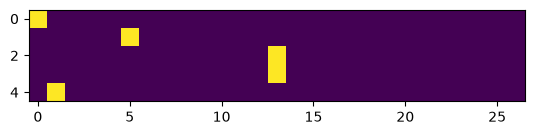

In [ ]:
plt.imshow(xenc.tolist())

In [ ]:
W = torch.randn((27, 27))
xenc @ W

tensor([[ 5.6379e-01,  3.1752e-01, -6.2672e-01, -8.2721e-01,  2.5653e-01,
          1.0847e-01,  5.6695e-03,  1.8860e-02,  6.5585e-01, -5.6781e-01,
         -1.7355e+00,  2.8219e-01,  1.0084e+00,  2.3342e-01, -7.4801e-01,
          3.7179e-01,  1.3007e+00, -1.4179e+00, -1.6749e+00, -3.8972e-02,
          8.4261e-01,  1.3111e+00, -9.9084e-03,  6.8422e-01, -1.0683e+00,
         -9.6575e-01,  1.5166e+00],
        [-1.2673e+00, -1.6345e-01, -1.4227e+00,  2.2784e-01, -1.1304e-03,
          1.2011e+00,  8.0234e-01, -8.4019e-01, -8.0869e-01,  1.0558e+00,
         -4.8013e-01,  1.6711e-01,  3.1398e-01,  1.3974e+00,  1.5700e+00,
          1.6748e+00, -3.5474e-01,  3.2965e-01, -2.4065e-02,  1.6146e+00,
          1.1410e+00, -4.7675e-01, -1.8463e-01,  1.4389e+00, -3.1180e-01,
          1.9053e+00, -1.8305e-02],
        [ 3.7734e-01,  7.1965e-01, -1.1691e+00, -3.2896e-02,  1.7112e-02,
          2.3135e-01,  2.3815e-01, -2.9342e-01, -3.4313e-01,  1.5762e+00,
         -3.1053e-02,  1.3598e+00, -3.43

In [ ]:
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
probs

: 

: 

: 

In [ ]:
!cd ~/Developer/MakeSumMore
python3 -m venv .venv
source .venv/bin/activate
pip install torch matplotlib ipykernel